In [47]:
import numpy as np
import pandas as pd
def shorten_config(cfg: str) -> str:
    # Rule 1: For configs with arc heuristics, drop sl/se/pe and keep only the arc values (e.g. "sup. | conf.")
    if "remove_arcs_heuristics=" in cfg or "add_arcs_heuristics=" in cfg:
        parts = [p.strip() for p in cfg.split("|")]
        rem = next(
            (
                p.replace("remove_arcs_heuristics=", "").strip()
                for p in parts
                if p.startswith("remove_arcs_heuristics=")
            ),
            "",
        )
        add = next(
            (
                p.replace("add_arcs_heuristics=", "").strip()
                for p in parts
                if p.startswith("add_arcs_heuristics=")
            ),
            "",
        )
        return f"{rem} | {add}"
    # Rule 2: Shorten basic heuristic flags to sl, se, pe
    parts = [p.strip() for p in cfg.split("|")]
    mapping = {
        "self_loops=True": "sl",
        "strict_end_activities=True": "se",
        "parallel_end_activities_heuristic=True": "pe",
    }
    return " | ".join([mapping.get(p, p) for p in parts])
# Load dataset and normalize sentinel values before analysis
df = pd.read_csv(r"C:\Users\elias\Desktop\final_results_thesis\df_results_new.csv")
df = df.replace(-1.0, 0)
df["configuration"] = df["configuration"].apply(shorten_config)
print(df["configuration"].unique())
# 3. Define configuration groupings (Baseline anchors present in both)
base_configs = ["IMf", "petrify", "No Heuristics"]
basic_extra = ["se", "pe", "se | pe", "sl", "sl | pe", "sl | se", "sl | se | pe"]
single_config = base_configs + basic_extra
arc_extra = [
    cfg for cfg in df["configuration"].unique() if cfg not in single_config
]
delta_config = base_configs + sorted(arc_extra)
# Split dataframes


['No Heuristics' 'pe' 'se' 'se | pe' 'sl' 'sl | pe' 'sl | se'
 'sl | se | pe' 'conf. | dep.' 'conf. | par.' 'conf. | sup.'
 'dep. | conf.' 'dep. | par.' 'dep. | sup.' 'excl. | conf.' 'excl. | dep.'
 'excl. | par.' 'excl. | sup.' 'sup. | conf.' 'sup. | dep.' 'sup. | par.'
 'IMf' 'petrify']


Average F1 without zeros

In [48]:
df_no_zeros = df.assign(
    f_1_score=df["f_1_score"].replace(0, np.nan),
    translucent_f_1_score=df["translucent_f_1_score"].replace(0, np.nan),
)
scenario2_discard_zeros = df_no_zeros.groupby(["algorithm", "configuration"])[
    ["f_1_score", "translucent_f_1_score"]
].mean()
print(scenario2_discard_zeros.sort_values("translucent_f_1_score", ascending=False))

                         f_1_score  translucent_f_1_score
algorithm configuration                                  
petrify   petrify         0.824516               0.982820
IMtf      sl | se         0.741371               0.821435
          sl | pe         0.718739               0.821257
          sl              0.724259               0.819850
          sl | se | pe    0.718388               0.819360
          excl. | dep.    0.703508               0.818104
          excl. | conf.   0.703508               0.818074
          excl. | sup.    0.703508               0.817861
          excl. | par.    0.703508               0.817529
IMts      dep. | par.     0.782743               0.815783
          conf. | dep.    0.782971               0.815639
          conf. | sup.    0.782147               0.815571
          excl. | par.    0.782743               0.815567
          dep. | sup.     0.782147               0.815539
          excl. | dep.    0.782971               0.815519
          excl

If one zero for a config exclude this scenario from mean

In [49]:
score_group_cols = ["dataset", "noise_type", "threshold"]
result_group_cols = ["algorithm", "configuration"]


def mean_excluding_zero_combinations(dataframe: pd.DataFrame, score_column: str) -> pd.DataFrame:
    zero_block = dataframe.groupby(score_group_cols)[score_column].transform(lambda values: (values == 0).any())
    filtered = dataframe.loc[~zero_block].copy()
    return filtered.groupby(result_group_cols)[score_column].mean().sort_values(ascending=False)


scenario3_exclude_zero_blocks = pd.concat(
    [
        mean_excluding_zero_combinations(df, "f_1_score").rename("f_1_score"),
        mean_excluding_zero_combinations(df, "translucent_f_1_score").rename("translucent_f_1_score"),
    ],
    axis=1,
)

print(scenario3_exclude_zero_blocks.sort_values("translucent_f_1_score", ascending=False))
print(scenario3_exclude_zero_blocks.sort_values("f_1_score", ascending=False))

                         f_1_score  translucent_f_1_score
algorithm configuration                                  
petrify   petrify         0.822021               0.981494
IMtf      sl | pe         0.721101               0.828368
          sl | se         0.745720               0.828255
IMts      dep. | par.     0.798465               0.826869
IMtf      sl              0.727105               0.826746
IMts      dep. | sup.     0.797808               0.826568
          excl. | par.    0.798465               0.826519
          conf. | sup.    0.797808               0.826511
          excl. | conf.   0.797809               0.826440
          conf. | par.    0.798465               0.826312
IMtf      sl | se | pe    0.720718               0.826220
IMts      conf. | dep.    0.797768               0.826197
          sup. | conf.    0.797809               0.826170
          excl. | dep.    0.797768               0.826071
          excl. | sup.    0.797808               0.825957
          sup.

In [50]:
import pandas as pd

score_group_cols = ["dataset", "noise_type", "threshold"]
result_group_cols = ["algorithm", "configuration"]

# Dynamically select all numeric columns, excluding score group columns
numeric_columns = [
    col
    for col in df.select_dtypes(include="number").columns
    if col not in score_group_cols
]

# 1. Identify rows where ANY numeric column is zero
has_zero_row = (df[numeric_columns] == 0).any(axis=1)

# 2. Flag entire score group if ANY row inside it contains a zero
group_has_zero = has_zero_row.groupby(
    [df[col] for col in score_group_cols]
).transform("any")

# 3. Compute means for all numeric columns on valid score groups
scenario4_exclude_zero_blocks = (
    df.loc[~group_has_zero]
    .groupby(result_group_cols)[numeric_columns]
    .mean()
    .sort_index()
)

print(scenario4_exclude_zero_blocks.sort_values("translucent_fitness", ascending=False))

                          fitness  translucent_fitness  precision  \
algorithm configuration                                             
petrify   petrify        1.000000             0.985923   0.794224   
IMtf      sl             0.922551             0.674106   0.656709   
          sl | pe        0.922551             0.674106   0.656709   
          sl | se        0.915007             0.665033   0.656442   
          sl | se | pe   0.931192             0.664421   0.633210   
          se | pe        0.935987             0.659416   0.577554   
          No Heuristics  0.927366             0.659353   0.584587   
          pe             0.927366             0.659353   0.584587   
          se             0.919365             0.658561   0.589057   
          dep. | sup.    0.914855             0.651858   0.654426   
          dep. | par.    0.914855             0.651858   0.654426   
          dep. | conf.   0.914855             0.651858   0.654426   
          conf. | par.   0.914858 

-> Continue with zeros

In [51]:
result_group_cols = ["algorithm", "configuration"]
numeric_columns = [
    column
    for column in df.select_dtypes(include="number").columns
    if column != "threshold"
]

scenario4_keep_zeros_all_columns = (
    df.groupby(result_group_cols)[numeric_columns]
    .mean()
    .sort_index()
)

print(scenario4_keep_zeros_all_columns.sort_values("fitness", ascending=False))
#print(scenario4_keep_zeros_all_columns.sort_values("translucent_fitness", ascending=False))
#print(scenario4_keep_zeros_all_columns.sort_values("precision", ascending=False))
#print(scenario4_keep_zeros_all_columns.sort_values("translucent_precision", ascending=False))
#print(scenario4_keep_zeros_all_columns.sort_values("simplicity", ascending=True))
#print(scenario4_keep_zeros_all_columns.sort_values("generalization", ascending=False))
#print(scenario4_keep_zeros_all_columns.sort_values("translucent_generalization", ascending=False))



                          fitness  translucent_fitness  precision  \
algorithm configuration                                             
petrify   petrify        0.933333             0.969606   0.720343   
IMtf      se | pe        0.912744             0.614839   0.580236   
          No Heuristics  0.909477             0.611885   0.586675   
          pe             0.909376             0.612774   0.580492   
IMts      conf. | dep.   0.906534             0.697799   0.705745   
          excl. | dep.   0.906534             0.697799   0.705745   
          sup. | dep.    0.906534             0.697799   0.705745   
          dep. | conf.   0.906428             0.697326   0.704447   
          conf. | sup.   0.906428             0.697326   0.704446   
          sup. | conf.   0.906428             0.697326   0.704447   
          excl. | sup.   0.906428             0.697326   0.704446   
          dep. | sup.    0.906428             0.697326   0.704446   
          excl. | conf.  0.906428 

In [52]:
result_group_cols = ["algorithm", "configuration"]
numeric_columns = [
    column
    for column in df.select_dtypes(include="number").columns
    if column != "threshold" and column != "fallthrough_count"
]

scenario5_keep_zeros_all_columns = df.groupby(result_group_cols)[numeric_columns].mean()

algorithm_order = {"IMtf": 0, "IMts": 1, "IMf": 2, "petrify": 3}
base_config_order = {"pe": 0, "se": 1, "sl": 2}


def configuration_sort_key(configuration: str) -> tuple:
    if configuration == "No Heuristics":
        return (0, 0, 0, configuration)

    pieces = [piece.strip() for piece in configuration.split("|")]
    if all(piece in base_config_order for piece in pieces):
        return (
            0,
            1,
            len(pieces),
            tuple(base_config_order[piece] for piece in pieces),
            configuration,
        )

    return (1, 0, 0, configuration)


sorted_table = scenario5_keep_zeros_all_columns.copy().reset_index()
sorted_table["algorithm_order"] = sorted_table["algorithm"].map(algorithm_order)
sorted_table["configuration_key"] = sorted_table["configuration"].map(configuration_sort_key)
sorted_table = sorted_table.sort_values(
    ["algorithm_order", "configuration_key", "configuration"]
).drop(columns=["algorithm_order", "configuration_key"])

formatted_table = sorted_table.copy()
for column in numeric_columns:
    column_maximum = sorted_table[column].max()
    formatted_table[column] = sorted_table[column].map(
        lambda value: "" if pd.isna(value) else (
            f"\\textbf{{{value:.4f}}}" if abs(value - column_maximum) < 1e-12 else f"{value:.4f}"
        )
    )

latex_output = formatted_table.to_latex(index=False, escape=False, na_rep="")
print(latex_output)

\begin{tabular}{lllllllllll}
\toprule
algorithm & configuration & fitness & translucent_fitness & precision & translucent_precision & f_1_score & translucent_f_1_score & simplicity & generalization & translucent_generalization \\
\midrule
IMtf & No Heuristics & 0.9095 & 0.6119 & 0.5867 & 0.8210 & 0.6772 & 0.6788 & 122.4788 & 0.9077 & 0.6328 \\
IMtf & pe & 0.9094 & 0.6128 & 0.5805 & 0.8209 & 0.6721 & 0.6793 & 122.9212 & 0.9076 & 0.6342 \\
IMtf & se & 0.8991 & 0.6089 & 0.6149 & 0.8261 & 0.6937 & 0.6788 & 121.5758 & 0.8973 & 0.6282 \\
IMtf & sl & 0.9029 & 0.6785 & 0.6208 & 0.9044 & 0.7067 & 0.7553 & 98.0182 & 0.9014 & 0.6968 \\
IMtf & se | pe & 0.9127 & 0.6148 & 0.5802 & 0.8205 & 0.6738 & 0.6801 & 122.7333 & 0.9086 & 0.6350 \\
IMtf & sl | pe & 0.9028 & 0.6751 & 0.6141 & 0.9049 & 0.7013 & 0.7516 & 98.3333 & 0.9014 & 0.6982 \\
IMtf & sl | se & 0.8925 & 0.6724 & 0.6491 & 0.9107 & 0.7234 & 0.7517 & 97.3818 & 0.8911 & 0.6934 \\
IMtf & sl | se | pe & 0.9062 & 0.6745 & 0.6100 & 0.9035 & 0.7010 &

Number of calculations that exceeded the time limit

In [53]:
# Calculates the number of zero entries per (algorithm, configuration) across thresholds for every numeric column
zero_counts = df.groupby(result_group_cols)[numeric_columns].apply(lambda x: (x == 0).sum()).astype(int)
print(zero_counts)

                         fitness  translucent_fitness  precision  \
algorithm configuration                                            
IMf       IMf                  0                    7          6   
IMtf      No Heuristics        0                   26          9   
          conf. | dep.         0                   18          5   
          conf. | par.         0                   18          5   
          conf. | sup.         0                   18          5   
          dep. | conf.         0                   17          5   
          dep. | par.          0                   17          5   
          dep. | sup.          0                   17          5   
          excl. | conf.        0                   17          5   
          excl. | dep.         0                   17          5   
          excl. | par.         0                   17          5   
          excl. | sup.         0                   17          5   
          pe                   0                

In [54]:
reference_table = sorted_table[["algorithm", "configuration"]].drop_duplicates().reset_index(drop=True)
reference_table["_order"] = range(len(reference_table))

sorted_table = zero_counts.copy().reset_index()
sorted_table = sorted_table.drop(columns=["simplicity"], errors="ignore")
sorted_table = sorted_table.merge(reference_table, on=["algorithm", "configuration"], how="left")
sorted_table = sorted_table.sort_values("_order").drop(columns=["_order"])

formatted_table = sorted_table.copy()
latex_output = formatted_table.to_latex(index=False, escape=False, na_rep="")
print(latex_output)

\begin{tabular}{llrrrrrrrr}
\toprule
algorithm & configuration & fitness & translucent_fitness & precision & translucent_precision & f_1_score & translucent_f_1_score & generalization & translucent_generalization \\
\midrule
IMtf & No Heuristics & 0 & 26 & 9 & 16 & 9 & 26 & 0 & 21 \\
IMtf & pe & 0 & 26 & 9 & 16 & 9 & 26 & 0 & 21 \\
IMtf & se & 0 & 26 & 9 & 16 & 9 & 26 & 0 & 21 \\
IMtf & sl & 0 & 13 & 4 & 5 & 4 & 13 & 0 & 9 \\
IMtf & se | pe & 0 & 26 & 9 & 16 & 9 & 26 & 0 & 21 \\
IMtf & sl | pe & 0 & 14 & 4 & 5 & 4 & 14 & 0 & 9 \\
IMtf & sl | se & 0 & 14 & 4 & 5 & 4 & 14 & 0 & 9 \\
IMtf & sl | se | pe & 0 & 14 & 4 & 5 & 4 & 14 & 0 & 9 \\
IMtf & conf. | dep. & 0 & 18 & 5 & 5 & 5 & 18 & 0 & 11 \\
IMtf & conf. | par. & 0 & 18 & 5 & 5 & 5 & 18 & 0 & 11 \\
IMtf & conf. | sup. & 0 & 18 & 5 & 5 & 5 & 18 & 0 & 11 \\
IMtf & dep. | conf. & 0 & 17 & 5 & 5 & 5 & 17 & 0 & 10 \\
IMtf & dep. | par. & 0 & 17 & 5 & 5 & 5 & 17 & 0 & 10 \\
IMtf & dep. | sup. & 0 & 17 & 5 & 5 & 5 & 17 & 0 & 10 \\
IMtf & ex

In [ ]:
# Code for heatmap

## Results per Dataset

Sepsis


In [55]:
sepsis_results = (
    df[df["dataset"] == "Sepsis"]
    .groupby(result_group_cols)[numeric_columns]
    .mean()
    .sort_index()
)

#print(sepsis_results)
print(sepsis_results.sort_values("f_1_score", ascending=False))
#print(sepsis_results.sort_values("fitness", ascending=False))


                          fitness  translucent_fitness  precision  \
algorithm configuration                                             
petrify   petrify        1.000000             0.927263   0.591705   
IMts      dep. | par.    0.917397             0.747956   0.634312   
          conf. | par.   0.917397             0.747956   0.634312   
          excl. | par.   0.917397             0.747956   0.634312   
          sup. | par.    0.917397             0.747956   0.634312   
          sup. | conf.   0.917427             0.747858   0.631325   
          excl. | conf.  0.917427             0.747858   0.631325   
          dep. | conf.   0.917427             0.747858   0.631325   
          excl. | sup.   0.917427             0.747858   0.631322   
          conf. | sup.   0.917427             0.747858   0.631322   
          dep. | sup.    0.917427             0.747858   0.631322   
          excl. | dep.   0.917427             0.747858   0.631205   
          conf. | dep.   0.917427 

Road Traffic Fine

In [56]:
road_traffic_results = (
    df[df["dataset"] == "road_traffic_fine"]
    .groupby(result_group_cols)[numeric_columns]
    .mean()
    .sort_index()
)

#rint(road_traffic_results)
print(road_traffic_results.sort_values("f_1_score", ascending=False))


                          fitness  translucent_fitness  precision  \
algorithm configuration                                             
petrify   petrify        1.000000             0.996448   0.786114   
IMts      se             0.916650             0.719358   0.840835   
          se | pe        0.916650             0.719333   0.840209   
          No Heuristics  0.916650             0.719333   0.840209   
          pe             0.916650             0.719333   0.840209   
          sl | se        0.913658             0.748112   0.826808   
          sl             0.913658             0.748087   0.826182   
          sl | pe        0.913658             0.748087   0.826182   
          sl | se | pe   0.913658             0.748087   0.826182   
IMf       IMf            0.921345             0.709693   0.826997   
IMts      conf. | par.   0.912165             0.746416   0.820614   
          dep. | par.    0.912165             0.746416   0.820614   
          dep. | sup.    0.912165 

Hospital Billing

In [57]:
hospital_billing_results = (
    df[df["dataset"] == "hospital_billing"]
    .groupby(result_group_cols)[numeric_columns]
    .mean()
    .sort_index()
)

#print(hospital_billing_results)
print(hospital_billing_results.sort_values("f_1_score", ascending=False))


                          fitness  translucent_fitness  precision  \
algorithm configuration                                             
IMts      excl. | dep.   0.890009             0.599125   0.665417   
          sup. | dep.    0.890009             0.599125   0.665417   
          conf. | dep.   0.890009             0.599125   0.665417   
          excl. | sup.   0.889692             0.597705   0.661403   
          conf. | sup.   0.889692             0.597705   0.661403   
          dep. | conf.   0.889692             0.597705   0.661403   
          excl. | conf.  0.889692             0.597705   0.661403   
          dep. | par.    0.889692             0.597705   0.661403   
          conf. | par.   0.889692             0.597705   0.661403   
          sup. | par.    0.889692             0.597705   0.661403   
          sup. | conf.   0.889692             0.597705   0.661403   
          excl. | par.   0.889692             0.597705   0.661403   
          dep. | sup.    0.889692 

# Results per noise_type

Base (no noise)

In [58]:
base_noise_results = (
    df[df["noise_type"] == "base"]
    .groupby(result_group_cols)[numeric_columns]
    .mean()
    .sort_index()
)

#print(base_noise_results)109
print(base_noise_results.sort_values("f_1_score", ascending=False))


                          fitness  translucent_fitness  precision  \
algorithm configuration                                             
petrify   petrify        1.000000             0.973254   0.781474   
IMts      excl. | sup.   0.931359             0.767343   0.711310   
          sup. | par.    0.931359             0.767343   0.711310   
          sup. | conf.   0.931359             0.767343   0.711310   
          dep. | par.    0.931359             0.767343   0.711310   
          dep. | sup.    0.931359             0.767343   0.711310   
          excl. | dep.   0.931359             0.767343   0.711310   
          conf. | dep.   0.931359             0.767343   0.711310   
          conf. | sup.   0.931359             0.767343   0.711310   
          dep. | conf.   0.931359             0.767343   0.711310   
          conf. | par.   0.931359             0.767343   0.711310   
          excl. | par.   0.931359             0.767343   0.711310   
          excl. | conf.  0.931359 

Remove_Enabled

In [59]:
remove_enabled_results = (
    df[df["noise_type"] == "remove_enabled"]
    .groupby(result_group_cols)[numeric_columns]
    .mean()
    .sort_index()
)

#print(remove_enabled_results)113
print(remove_enabled_results.sort_values("f_1_score", ascending=False))


                          fitness  translucent_fitness  precision  \
algorithm configuration                                             
petrify   petrify        1.000000             0.965990   0.716572   
IMts      excl. | sup.   0.912572             0.728243   0.761557   
          sup. | par.    0.912572             0.728243   0.761557   
          sup. | conf.   0.912572             0.728243   0.761557   
          dep. | par.    0.912572             0.728243   0.761557   
          dep. | sup.    0.912572             0.728243   0.761557   
          excl. | dep.   0.912572             0.728243   0.761557   
          conf. | dep.   0.912572             0.728243   0.761557   
          conf. | sup.   0.912572             0.728243   0.761557   
          dep. | conf.   0.912572             0.728243   0.761557   
          conf. | par.   0.912572             0.728243   0.761557   
          excl. | par.   0.912572             0.728243   0.761557   
          excl. | conf.  0.912572 

Remove Events

In [60]:
remove_events_results = (
    df[df["noise_type"] == "remove_events"]
    .groupby(result_group_cols)[numeric_columns]
    .mean()
    .sort_index()
)

#print(remove_events_results)116
print(remove_events_results.sort_values("f_1_score", ascending=False))


                          fitness  translucent_fitness  precision  \
algorithm configuration                                             
IMts      sl | se | pe   0.899365             0.694929   0.792259   
          sl | se        0.899365             0.694929   0.792259   
          sl | pe        0.899365             0.694929   0.792259   
          sl             0.899365             0.694929   0.792259   
          se             0.903650             0.696720   0.787004   
          se | pe        0.903650             0.696720   0.787004   
          pe             0.903650             0.696720   0.787004   
          No Heuristics  0.903650             0.696720   0.787004   
          conf. | sup.   0.903029             0.720761   0.789563   
          dep. | par.    0.903029             0.720761   0.789563   
          conf. | par.   0.903029             0.720761   0.789563   
          dep. | sup.    0.903029             0.720761   0.789563   
          sup. | conf.   0.903029 

Add Enabled

In [61]:
add_enabled_results = (
    df[df["noise_type"] == "add_enabled"]
    .groupby(result_group_cols)[numeric_columns]
    .mean()
    .sort_index()
)

#print(add_enabled_results)114
print(add_enabled_results.sort_values("f_1_score", ascending=False))


                          fitness  translucent_fitness  precision  \
algorithm configuration                                             
petrify   petrify        1.000000             0.968451   0.652207   
IMts      sl | se        0.921853             0.703892   0.696396   
          sl             0.921853             0.703850   0.695352   
          sl | pe        0.921853             0.703850   0.695352   
          sl | se | pe   0.921853             0.703850   0.695352   
          conf. | sup.   0.928876             0.734061   0.681365   
          conf. | par.   0.928876             0.734061   0.681365   
          dep. | conf.   0.928876             0.734061   0.681365   
          dep. | par.    0.928876             0.734061   0.681365   
          dep. | sup.    0.928876             0.734061   0.681365   
          excl. | dep.   0.928876             0.734061   0.681365   
          excl. | conf.  0.928876             0.734061   0.681365   
          sup. | par.    0.928876 

Add Events

In [62]:
add_events_results = (
    df[df["noise_type"] == "add_events_no_trans"]
    .groupby(result_group_cols)[numeric_columns]
    .mean()
    .sort_index()
)

#print(add_events_results)176
print(add_events_results.sort_values("f_1_score", ascending=False))


                          fitness  translucent_fitness  precision  \
algorithm configuration                                             
IMts      excl. | dep.   0.856832             0.538589   0.584932   
          sup. | dep.    0.856832             0.538589   0.584932   
          conf. | dep.   0.856832             0.538589   0.584932   
          conf. | par.   0.856254             0.536386   0.583421   
          sup. | par.    0.856254             0.536386   0.583421   
          dep. | par.    0.856254             0.536386   0.583421   
          excl. | par.   0.856254             0.536386   0.583421   
          dep. | conf.   0.856304             0.536223   0.578441   
          excl. | conf.  0.856304             0.536223   0.578441   
          sup. | conf.   0.856304             0.536223   0.578441   
          excl. | sup.   0.856304             0.536223   0.578437   
          dep. | sup.    0.856304             0.536223   0.578437   
          conf. | sup.   0.856304 

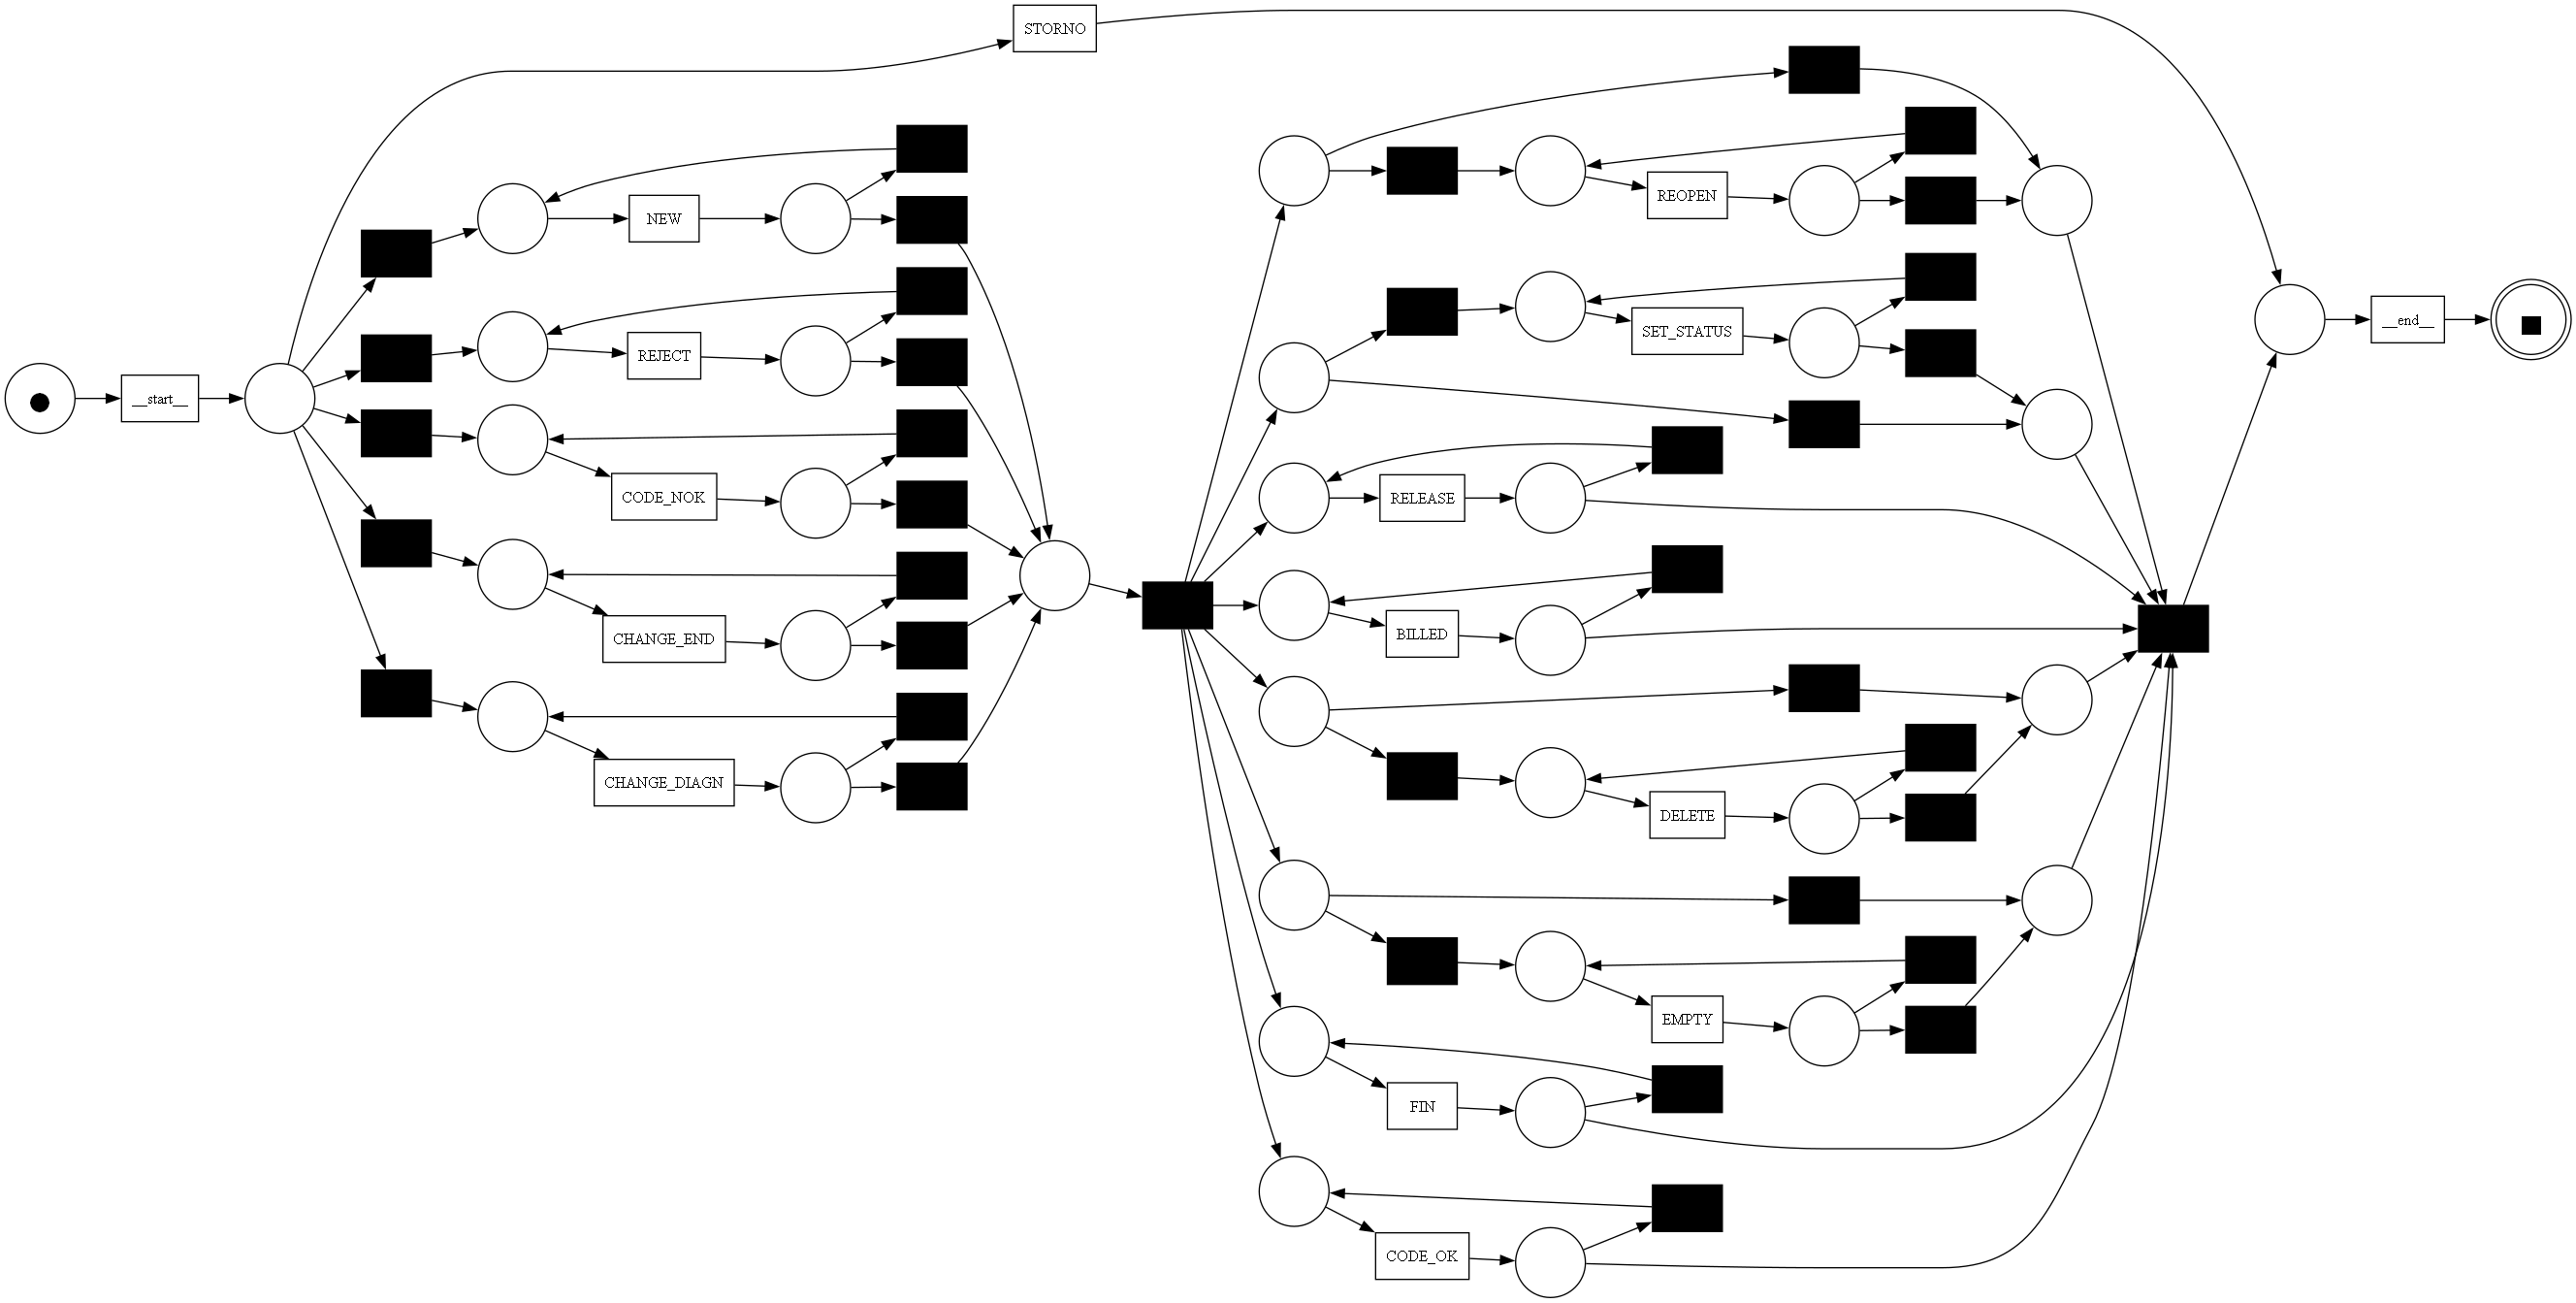

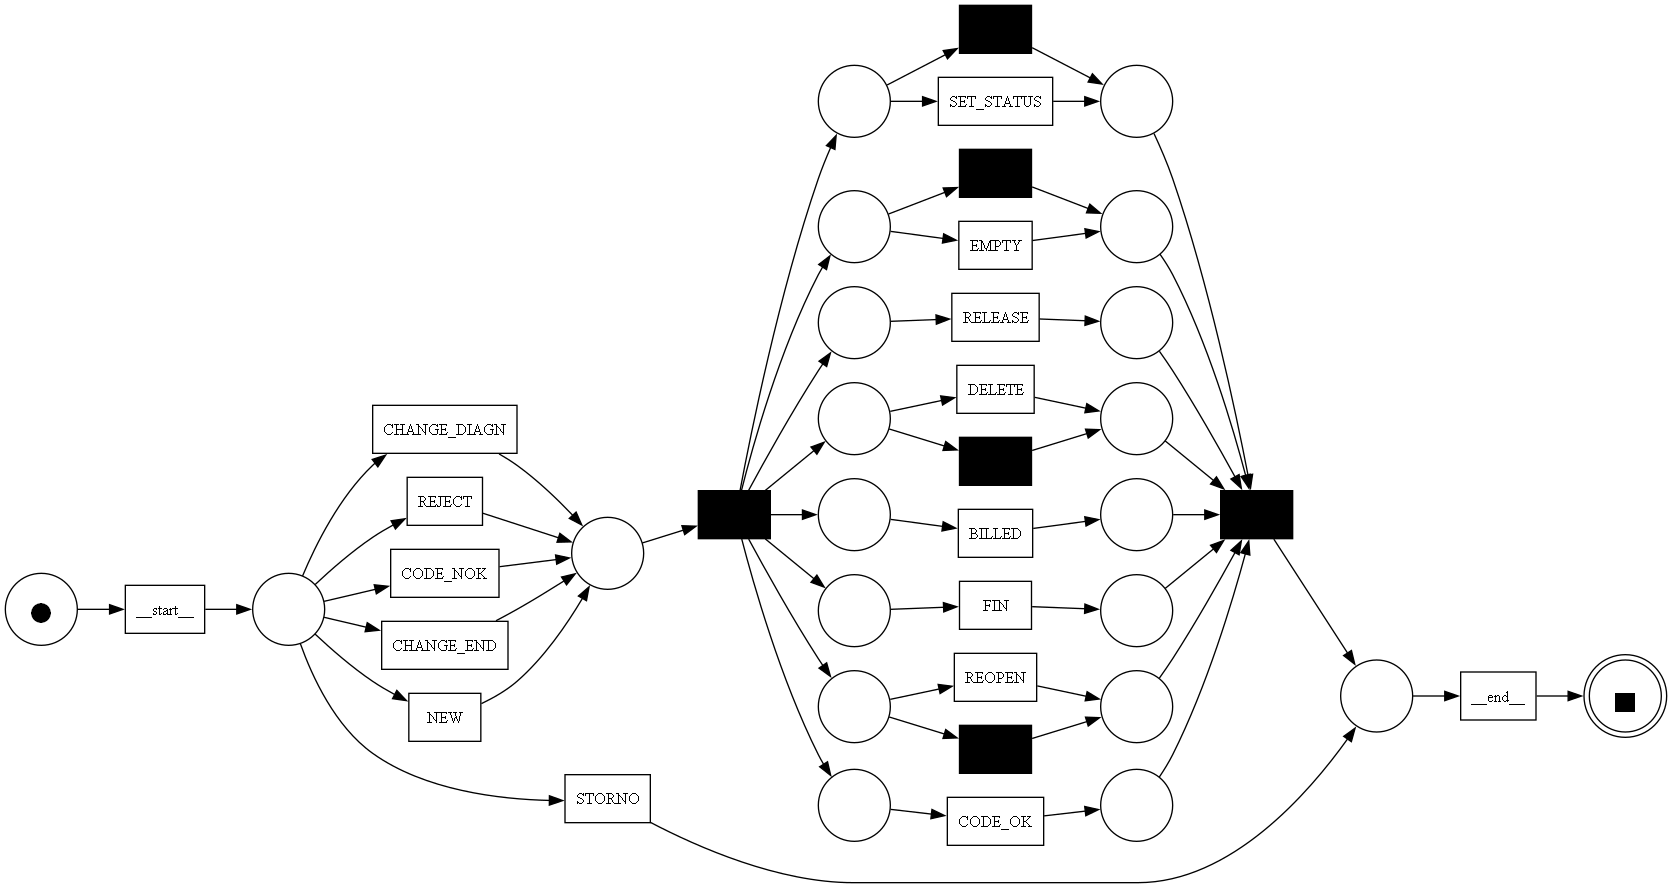

In [63]:
import pm4py
# ohne
net, im, fm =pm4py.read_pnml(r"C:\EVAL_F~1\new_eval\TRANSL~1\HOSPIT~1\pnml\TRANSL~1\ADD_EV~1\TR22EE~1\NEA5C1~1.PNM")
pm4py.view_petri_net(net, im, fm)
# mit
net, im, fm =pm4py.read_pnml(r"C:\EVAL_F~1\new_eval\TRANSL~1\HOSPIT~1\pnml\TRANSL~1\ADD_EV~1\TRANSL~1\NEA5C1~1.PNM")
pm4py.view_petri_net(net, im, fm)

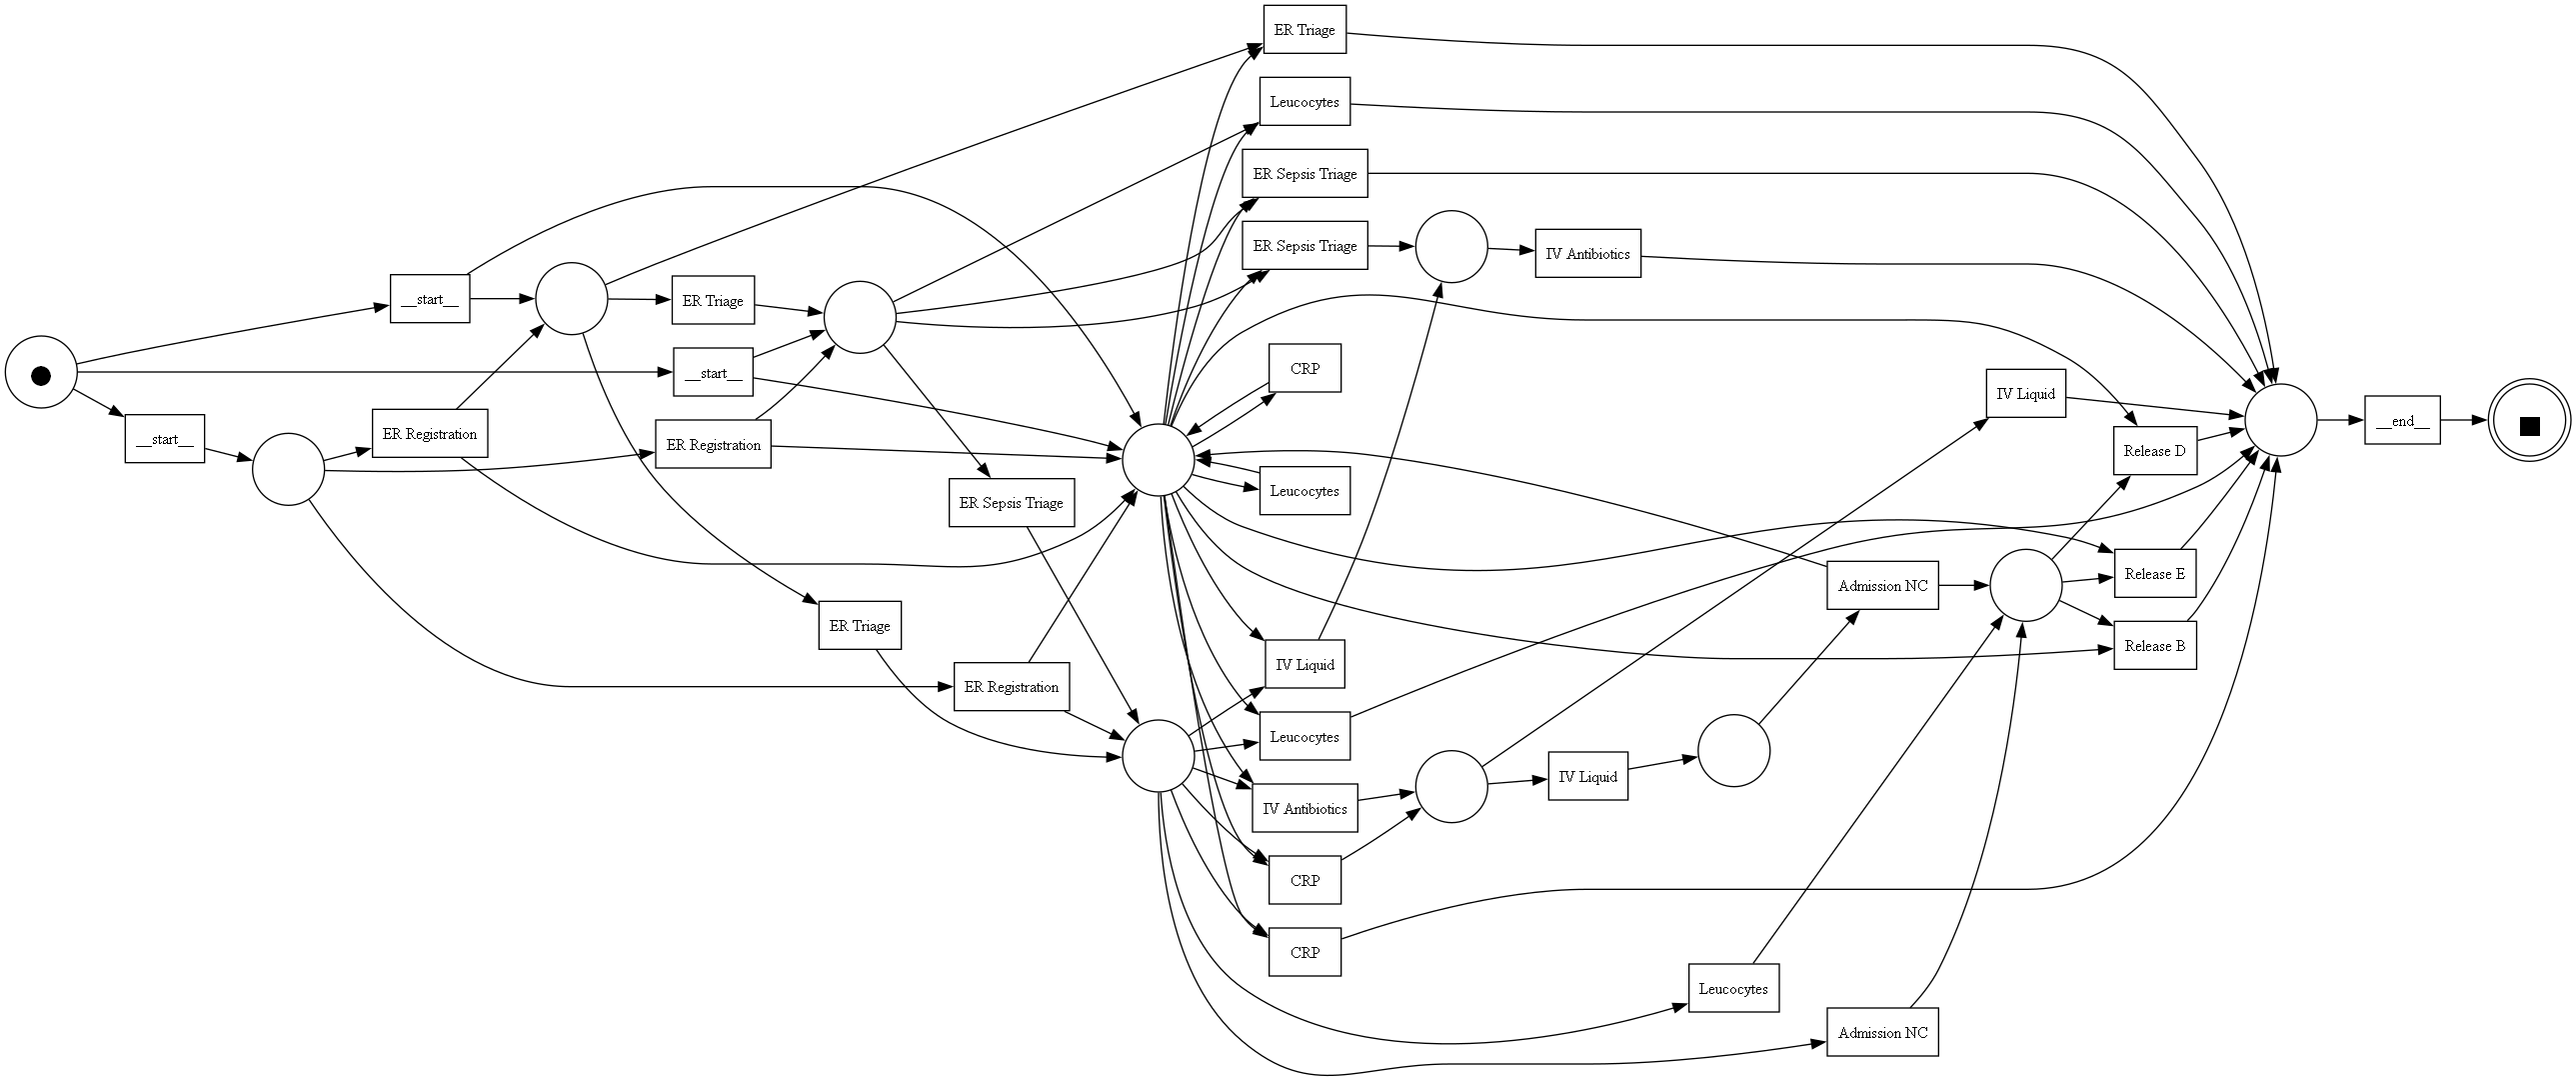

In [64]:
net, im, fm =pm4py.read_pnml(r"C:\eval_fall\new_eval\translucent_datasets\Sepsis\pnml\petrify\remove_events\petrify.pnml")
pm4py.view_petri_net(net, im, fm)